In [ ]:
# ==============================================================================
# Célula 1 - EXTRAÇÃO TOTAL (S1, MODIS, SMAP)
# Foco: VH, VV, SE, DoP vs NDVI, NDWI, LST, ET, Solo
# ==============================================================================

import ee
import pandas as pd
import numpy as np

try:
    ee.Initialize(project="1024249618890")
    print("✅ GEE Inicializado!")
except:
    ee.Authenticate()
    ee.Initialize(project="1024249618890")

import requests
import json
import ee
import pandas as pd

# 1. Parâmetros de Caconde
COD_MUN = "3508702"

# 2. Requisição direta à API do IBGE para buscar a malha oficial em formato GeoJSON
url_ibge = f'https://servicodados.ibge.gov.br/api/v3/malhas/municipios/{COD_MUN}?formato=application/vnd.geo+json'
resposta = requests.get(url_ibge)

if resposta.status_code == 200:
    geojson_dados = resposta.json()
    # 3. Converte o GeoJSON do IBGE diretamente em uma Geometria nativa do Earth Engine
    # O GEE lê a estrutura 'features' do padrão GeoJSON perfeitamente
    geom = ee.Geometry(geojson_dados['features'][0]['geometry'])
    print("✅ Malha oficial de Caconde integrada via API do IBGE!")
else:
    raise RuntimeError(f"Falha ao conectar com a API do IBGE. Status Code: {resposta.status_code}")

# 4. Continuidade do seu pipeline original
mascara_cafe = ee.Image("projects/mapbiomas-public/assets/brazil/lulc/collection9/mapbiomas_collection90_integration_v1").select('classification_2022').eq(46)
datas = pd.date_range(start='2015-01-01', end='2025-12-31', freq='16D')

def extrair_tudo_final(d):
    inicio = ee.Date(d.strftime('%Y-%m-%d'))
    fim = inicio.advance(16, 'day')

    # --- 1. RADAR (SENTINEL-1) ---
    s1_coll = ee.ImageCollection('COPERNICUS/S1_GRD') \
        .filterBounds(geom) \
        .filterDate(inicio, fim) \
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
    s1_img = s1_coll.median()

    # Conversão para Linear para métricas estruturais
    vh_lin = ee.Image(10).pow(s1_img.select('VH').divide(10))
    vv_lin = ee.Image(10).pow(s1_img.select('VV').divide(10))

    # SE (Entropia) e DoP (Grau de Polarização)
    se = vh_lin.add(vv_lin).log().rename('SE')
    dop = vv_lin.subtract(vh_lin).divide(vv_lin.add(vh_lin)).rename('DoP')

    # --- 2. ÓPTICO (MODIS) ---
    mod09_coll = ee.ImageCollection("MODIS/061/MOD09A1").filterDate(inicio, fim)
    img09 = mod09_coll.median()
    ndvi = img09.normalizedDifference(['sur_refl_b02', 'sur_refl_b01']).rename('NDVI')
    ndwi = img09.normalizedDifference(['sur_refl_b02', 'sur_refl_b06']).rename('NDWI')

    # --- 3. TÉRMICO, ET e SOLO ---
    lst_coll = ee.ImageCollection("MODIS/061/MOD11A2").filterDate(inicio, fim)
    et_coll = ee.ImageCollection("MODIS/061/MOD16A2").filterDate(inicio, fim)
    smap_coll = ee.ImageCollection("NASA/SMAP/SPL4SMGP/008").filterDate(inicio, fim)

    # Função de redução robusta
    def reduzir_safe(col, img_proc, banda, scale, factor=1, offset=0):
        condicao = col.size().gt(0)
        return ee.Algorithms.If(condicao,
                               img_proc.select(banda).multiply(factor).add(offset).updateMask(mascara_cafe)
                                  .reduceRegion(ee.Reducer.mean(), geom, scale).get(banda), None)

    return ee.Feature(None, {
        'data': inicio.format('YYYY-MM-dd'),
        'VH': reduzir_safe(s1_coll, s1_img, 'VH', 30),
        'SE': reduzir_safe(s1_coll, se, 'SE', 30),
        'DoP': reduzir_safe(s1_coll, dop, 'DoP', 30),
        'NDVI': reduzir_safe(mod09_coll, ndvi, 'NDVI', 500),
        'NDWI': reduzir_safe(mod09_coll, ndwi, 'NDWI', 500),
        'LST': reduzir_safe(lst_coll, lst_coll.median(), 'LST_Day_1km', 1000, 0.02, -273.15),
        'ET': reduzir_safe(et_coll, et_coll.median(), 'ET', 500, 0.1),
        'Soil_Moisture': reduzir_safe(smap_coll, smap_coll.median(), 'sm_surface', 10000)
    })

print("🚀 Minerando Super-Matriz (VH, SE, DoP + Todos)...")
features = []
for i in range(0, len(datas), 50):
    segmento = datas[i:i+50]
    features.extend(ee.FeatureCollection(ee.List([extrair_tudo_final(d) for d in segmento])).getInfo()['features'])

df_final = pd.DataFrame([f['properties'] for f in features]).dropna(subset=['VH', 'SE', 'NDVI', 'Soil_Moisture']).reset_index(drop=True)
df_final['data'] = pd.to_datetime(df_final['data'])

print(f"✅ Concluído! Amostras válidas: {len(df_final)}")

✅ GEE Inicializado!
✅ Malha oficial de Caconde integrada via API do IBGE!
🚀 Minerando Super-Matriz (VH, SE, DoP + Todos)...
✅ Concluído! Amostras válidas: 240


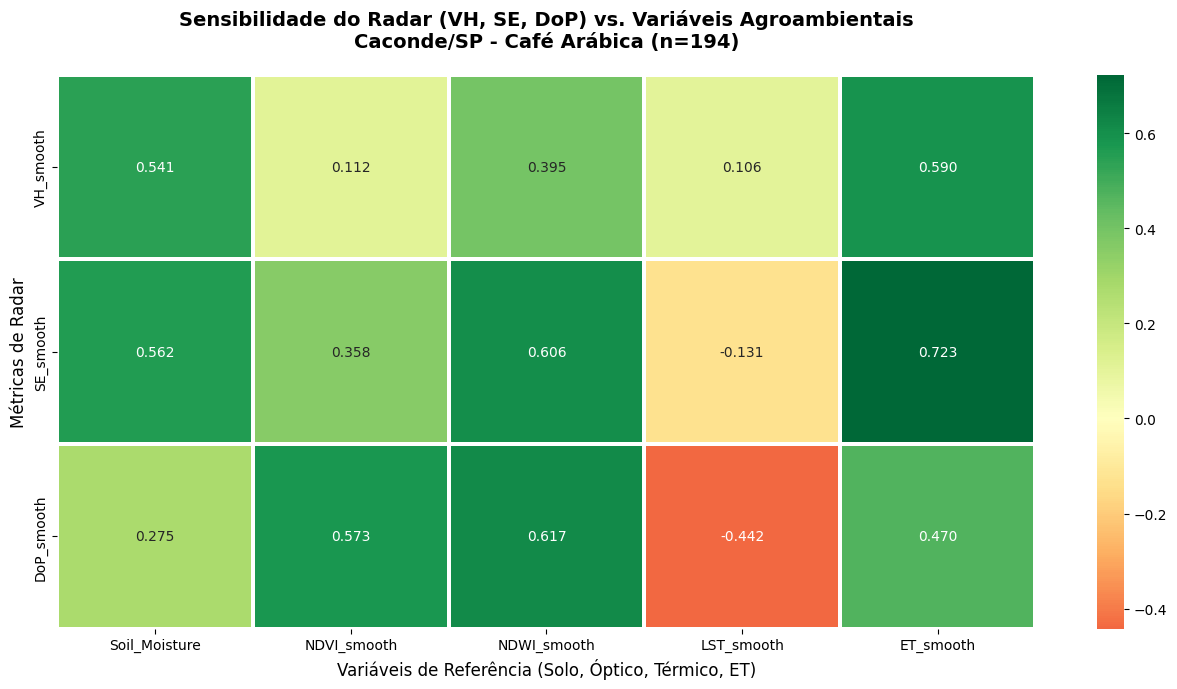

----------------------------------------------------------------------
🏆 ANÁLISE DE CAPACIDADE DE MONITORAMENTO:
➜ Para Soil_Moisture | Melhor Radar: SE_smooth  | r = 0.562
➜ Para NDVI         | Melhor Radar: DoP_smooth | r = 0.573
➜ Para NDWI         | Melhor Radar: DoP_smooth | r = 0.617
➜ Para LST          | Melhor Radar: DoP_smooth | r = -0.442
➜ Para ET           | Melhor Radar: SE_smooth  | r = 0.723
----------------------------------------------------------------------


In [ ]:
# ==============================================================================
# Célula 2 - CONFRONTO TOTAL (Radar Avançado vs. Consagrados)
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter

# 1. Suavização das Séries Temporais
cols_radar = ['VH', 'SE', 'DoP']
cols_consagrados = ['NDVI', 'NDWI', 'LST', 'ET']
todas = cols_radar + cols_consagrados

for col in todas:
    df_final[f'{col}_smooth'] = savgol_filter(df_final[col].interpolate(), window_length=5, polyorder=2)

# 2. Eixos da Matriz (Suavizados)
radar_targets = [f'{c}_smooth' for c in cols_radar]
referencia_targets = ['Soil_Moisture'] + [f'{c}_smooth' for c in cols_consagrados]

# 3. Cálculo da Correlação Filtrada
# Linhas: Métricas de Radar | Colunas: Indicadores Consagrados
matriz_confronto = df_final[radar_targets + referencia_targets].corr().loc[radar_targets, referencia_targets]

# 4. Heatmap Científico
plt.figure(figsize=(13, 7))
sns.heatmap(matriz_confronto, annot=True, cmap='RdYlGn', center=0, fmt=".3f",
            linewidths=1.5, square=False)

plt.title('Sensibilidade do Radar (VH, SE, DoP) vs. Variáveis Agroambientais\nCaconde/SP - Café Arábica (n=194)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Variáveis de Referência (Solo, Óptico, Térmico, ET)', fontsize=12)
plt.ylabel('Métricas de Radar', fontsize=12)
plt.tight_layout()
plt.show()

# 5. Resumo de Performance
print("-" * 70)
print("🏆 ANÁLISE DE CAPACIDADE DE MONITORAMENTO:")
for ref in referencia_targets:
    best_radar = matriz_confronto[ref].abs().idxmax()
    r_val = matriz_confronto.loc[best_radar, ref]
    print(f"➜ Para {ref.replace('_smooth',''):<12} | Melhor Radar: {best_radar:<10} | r = {r_val:.3f}")
print("-" * 70)

⏳ Computing temporal time-lags between Canopy Structure and Crop Metabolism...


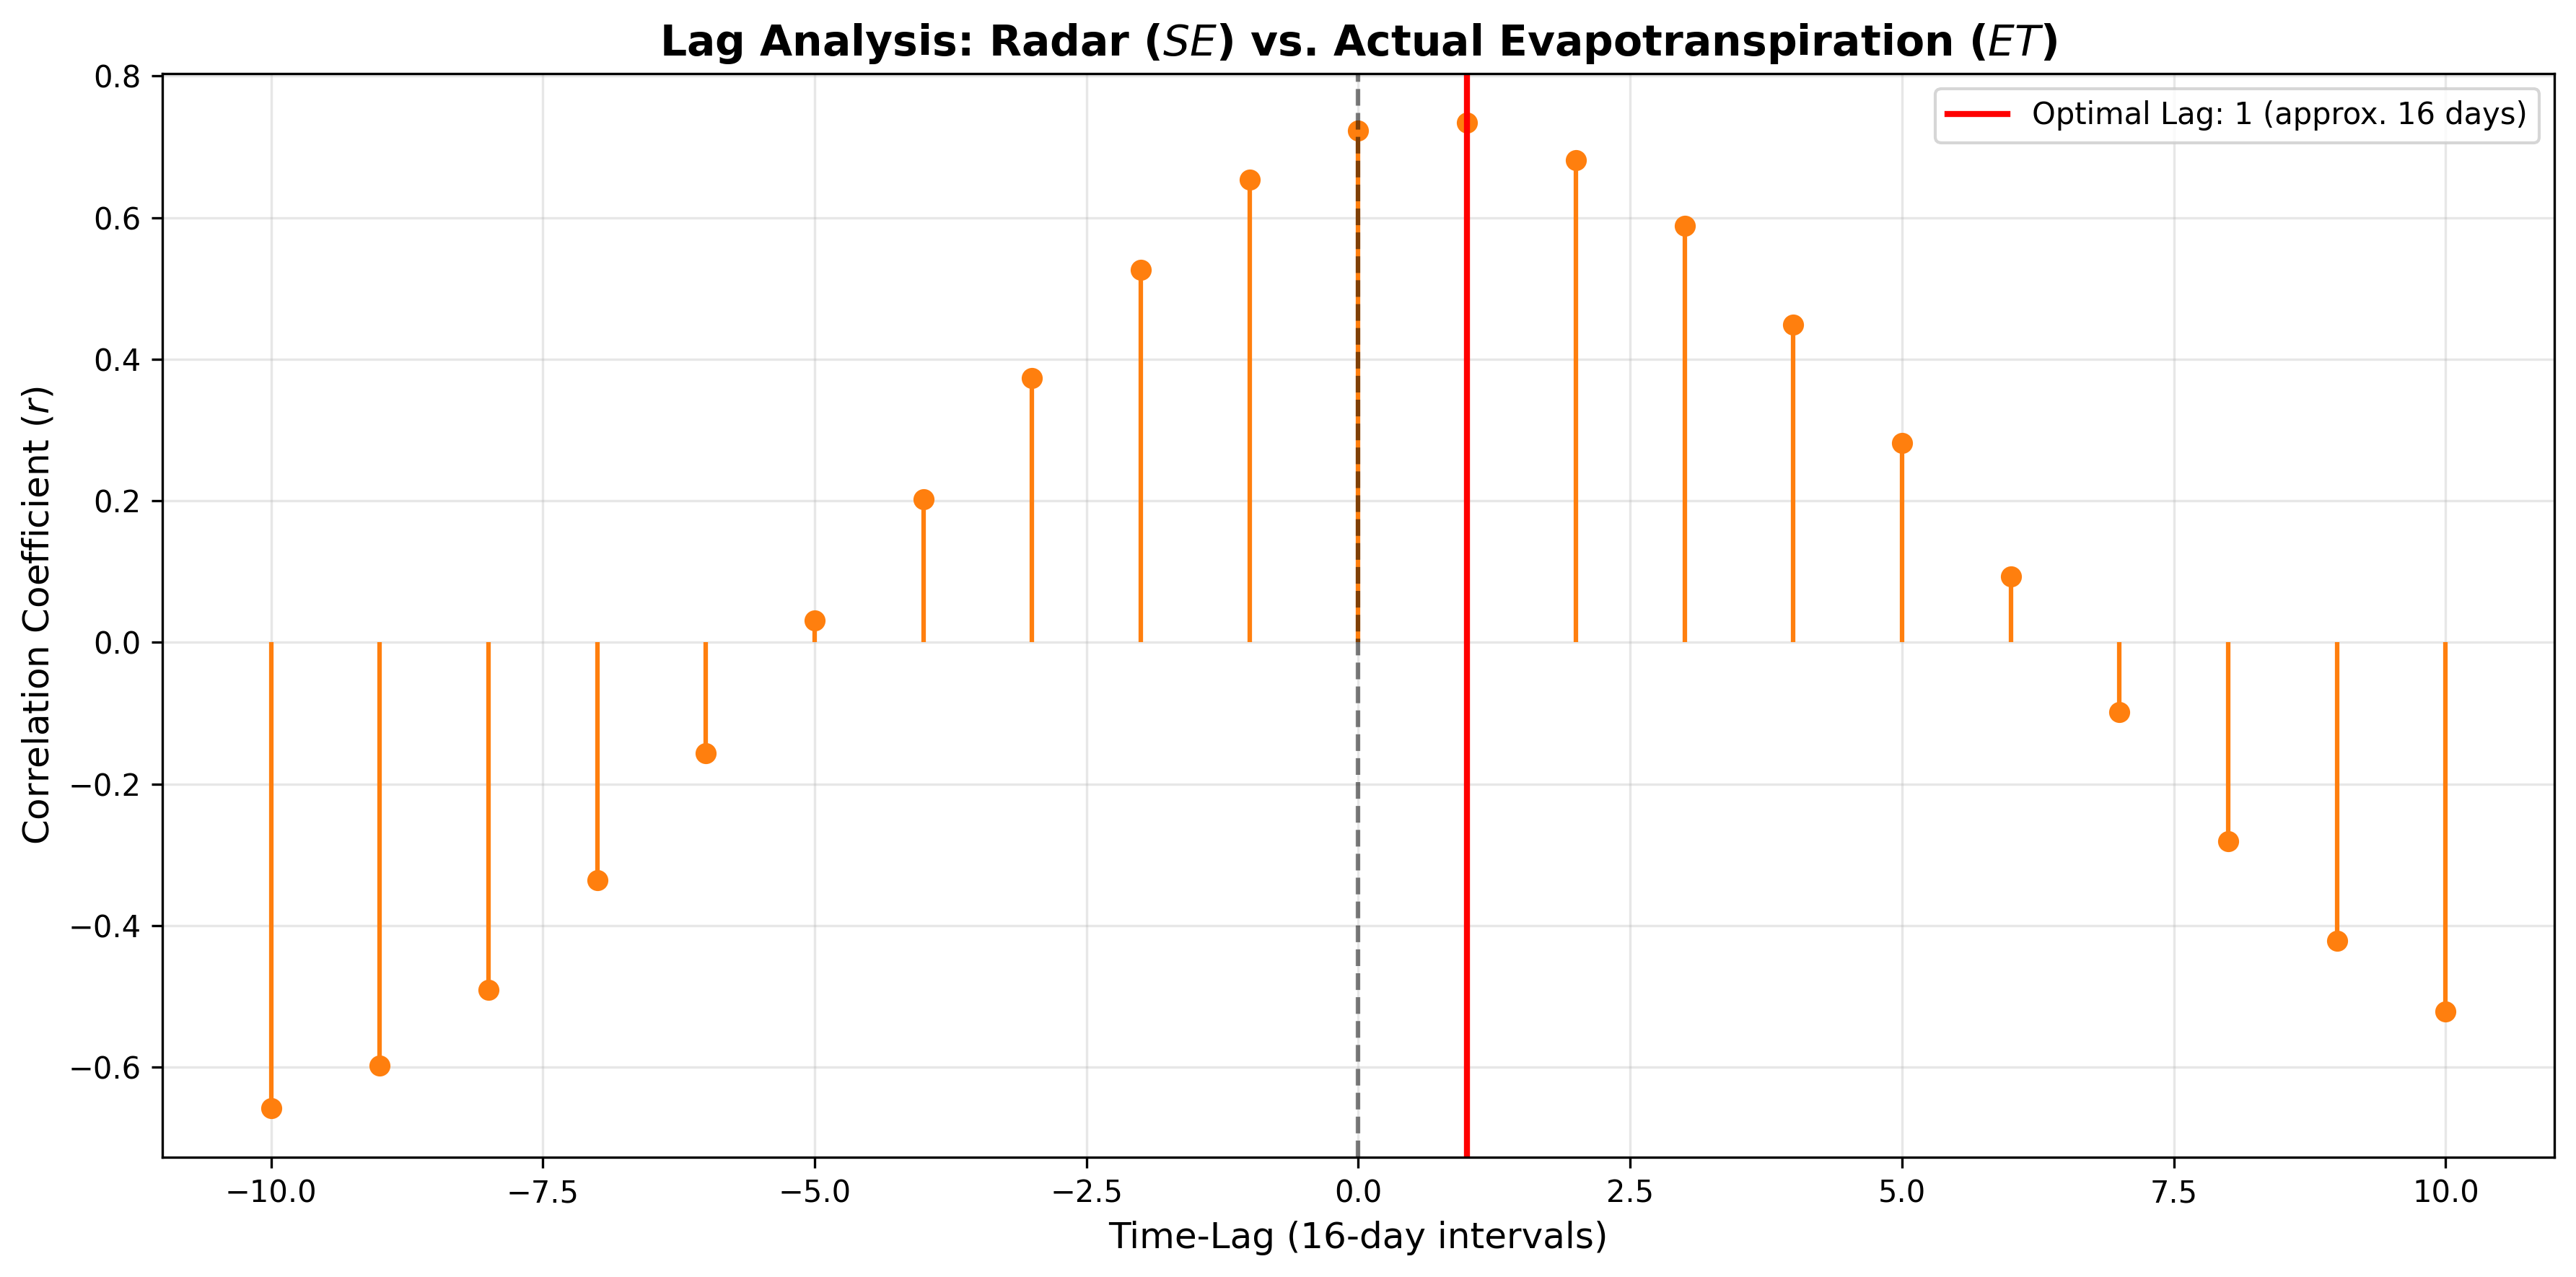

----------------------------------------------------------------------
📌 LAG ANALYSIS RESULTS:
➜ ETa PRECEDES geometric canopy alterations by 16 days (r = 0.734)
----------------------------------------------------------------------


In [ ]:
# ==============================================================================
# Cell 4 - CROSS-CORRELATION ANALYSIS (LAG ANALYSIS)
# Objective: Identify if Radar (SE) detects water stress prior to ETa shifts.
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt

# 1. Globally configure Matplotlib to render directly on screen at 300 DPI
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

print("⏳ Computing temporal time-lags between Canopy Structure and Crop Metabolism...")

# 2. Series Preparation (Z-score Normalization)
se_series = (df_final['SE_smooth'] - df_final['SE_smooth'].mean()) / df_final['SE_smooth'].std()
et_series = (df_final['ET_smooth'] - df_final['ET_smooth'].mean()) / df_final['ET_smooth'].std()

# 3. Cross-Correlation Calculation across different Lags (16-day observation cycles)
lags = np.arange(-10, 11) # Testing from -160 to +160 days
corrs = [se_series.corr(et_series.shift(lag)) for lag in lags]

# 4. Identification of the optimal maximum correlation lag
max_corr_idx = np.argmax(np.abs(corrs))
max_lag = lags[max_corr_idx]
max_r = corrs[max_corr_idx]

# 5. High-Resolution Lag Plotting
plt.figure(figsize=(12, 6))
plt.stem(lags, corrs, basefmt=" ", linefmt='C1-', markerfmt='C1o')
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.axvline(max_lag, color='red', linestyle='-', linewidth=2,
            label=f'Optimal Lag: {max_lag} (approx. {max_lag*16} days)')

plt.title('Lag Analysis: Radar ($SE$) vs. Actual Evapotranspiration ($ET$)', fontsize=14, fontweight='bold')
plt.xlabel('Time-Lag (16-day intervals)', fontsize=12)
plt.ylabel('Correlation Coefficient ($r$)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("-" * 70)
print(f"📌 LAG ANALYSIS RESULTS:")
if max_lag < 0:
    print(f"➜ RADAR PRECEDES ETa changes by {abs(max_lag)*16} days (r = {max_r:.3f})")
elif max_lag > 0:
    print(f"➜ ETa PRECEDES geometric canopy alterations by {max_lag*16} days (r = {max_r:.3f})")
else:
    print(f"➜ SIMULTANEOUS RESPONSE detected (Lag 0, r = {max_r:.3f})")
print("-" * 70)

📊 DISPONIBILIDADE DE DADOS POR ANO (Amostras Válidas):
      VH  SE  NDVI  NDWI  LST  ET  Soil_Moisture
ano                                             
2015  14  14    14    14   14   0             14
2016  22  22    22    22   22   0             22
2017  23  23    23    23   22   0             23
2018  23  23    23    23   23   0             23
2019  23  23    23    23   23   0             23
2020  22  22    22    22   22   0             22
2021  22  22    22    22   22  22             22
2022  23  23    23    23   23  23             23
2023  22  22    22    22   22  22             22
2024  23  23    23    23   23  23             23
2025  23  23    23    23   23  23             23


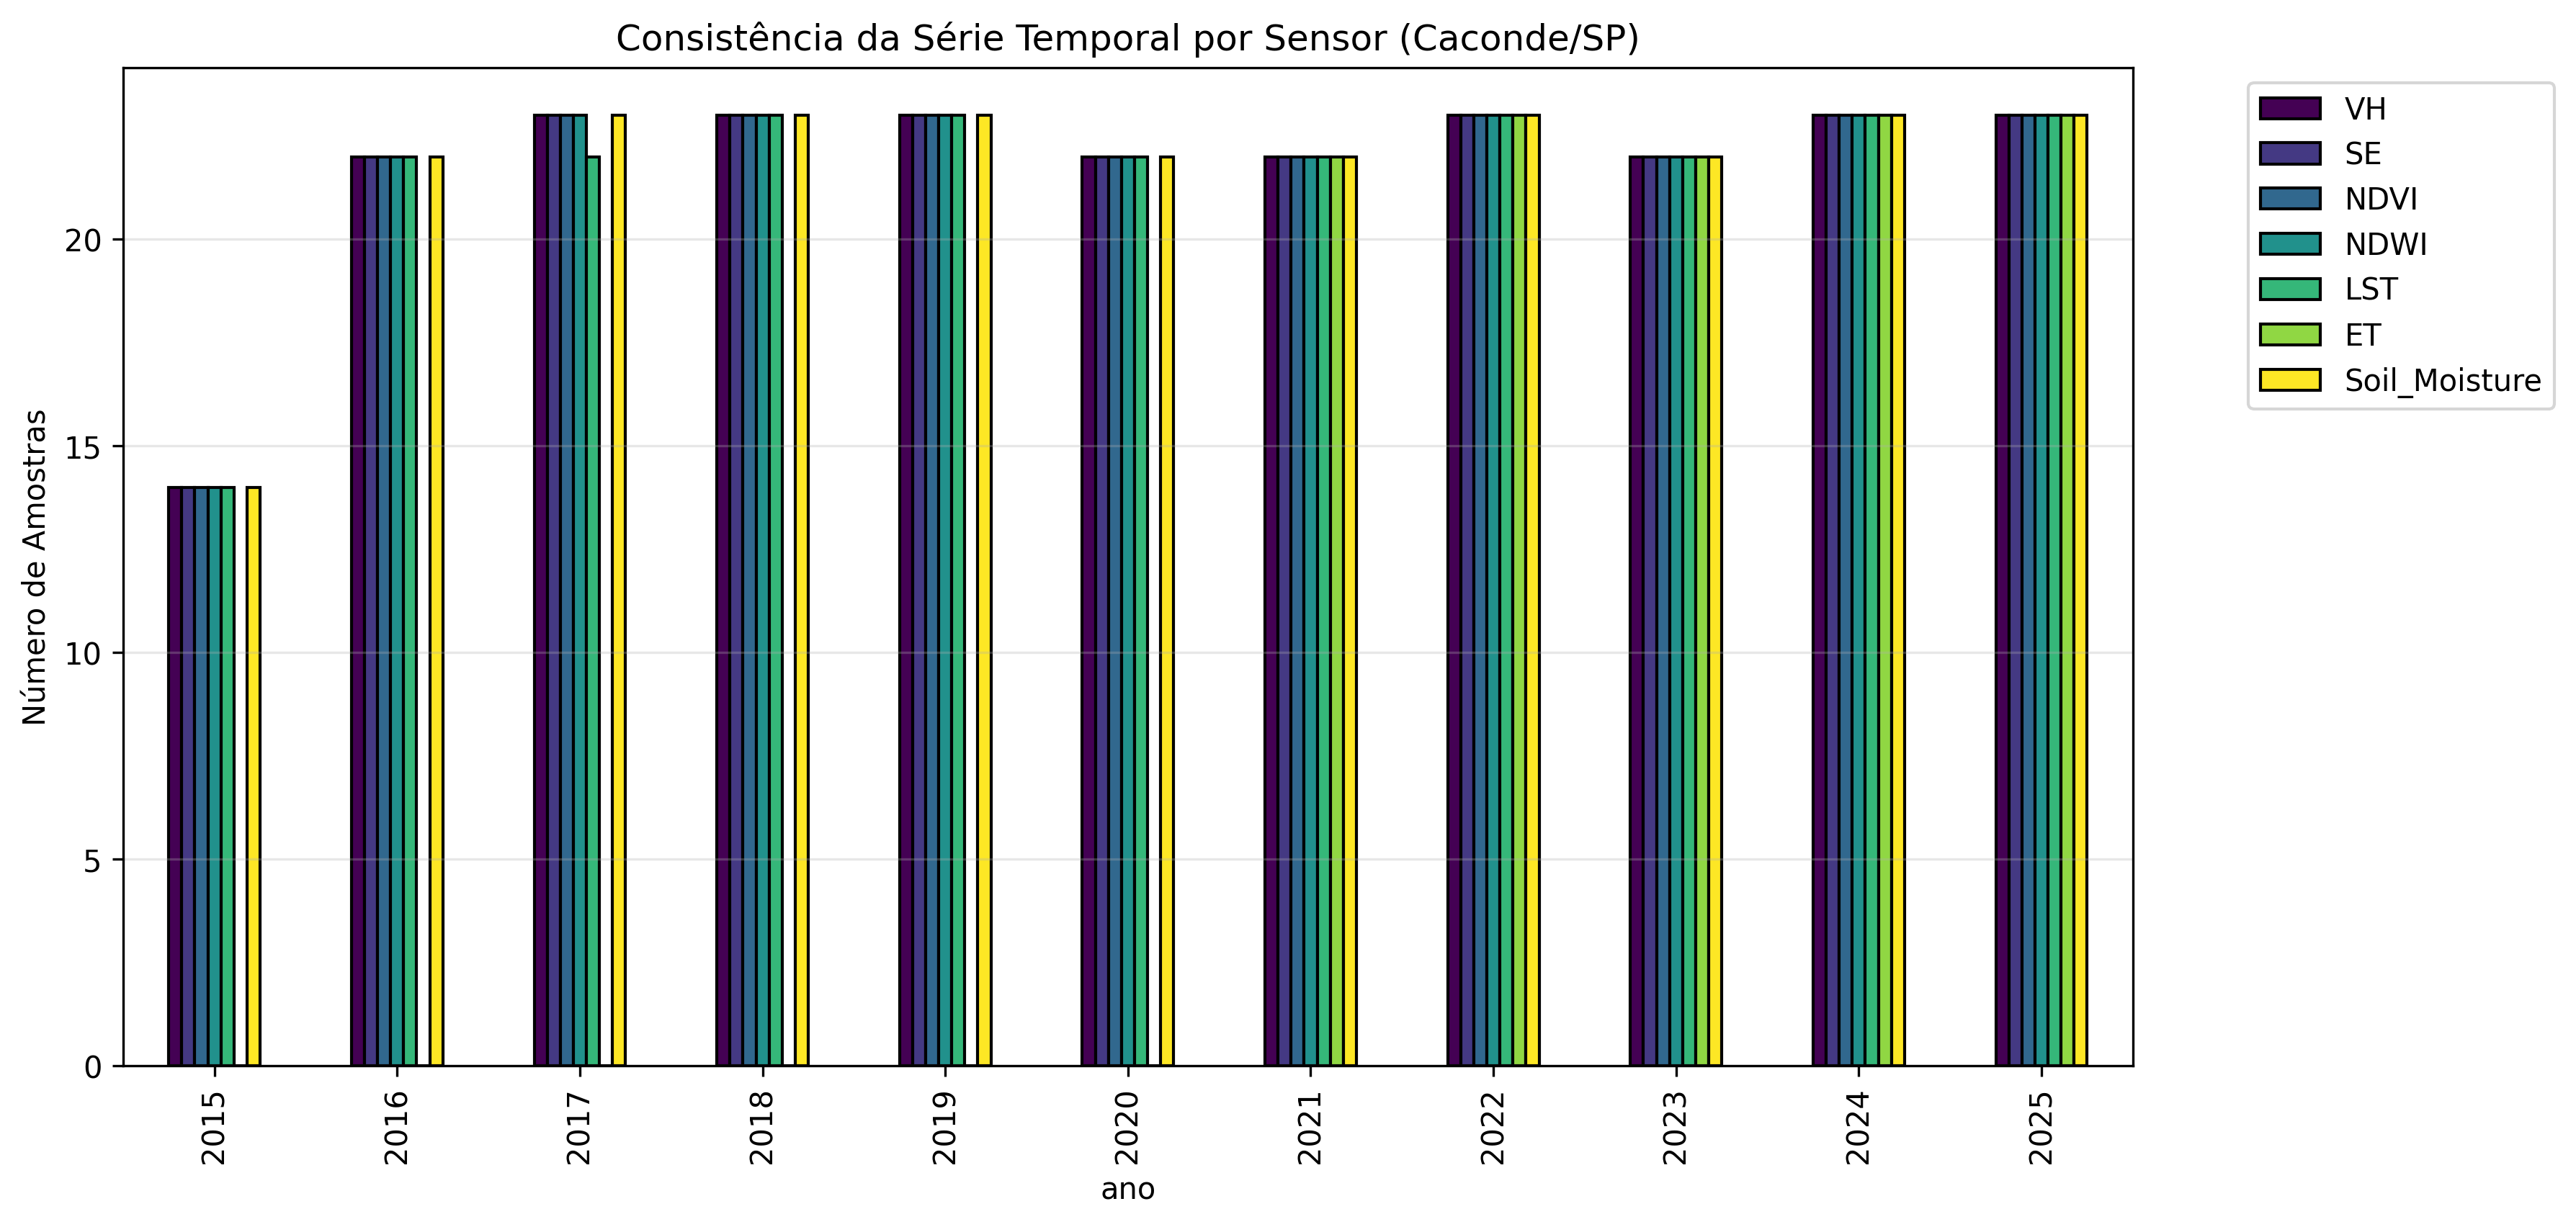

In [ ]:
# ==============================================================================
# Cell 5 - DIAGNÓSTICO DE DADOS - Quantas amostras temos por ano?
# ==============================================================================

df_diag = df_final.copy()
df_diag['ano'] = df_diag['data'].dt.year

# Contagem de valores não-nulos por ano para cada sensor
contagem_anual = df_diag.groupby('ano')[['VH', 'SE', 'NDVI', 'NDWI', 'LST', 'ET', 'Soil_Moisture']].count()

print("📊 DISPONIBILIDADE DE DADOS POR ANO (Amostras Válidas):")
print(contagem_anual)

# Visualização rápida
contagem_anual.plot(kind='bar', figsize=(12, 6), cmap='viridis', edgecolor='black')
plt.title('Consistência da Série Temporal por Sensor (Caconde/SP)')
plt.ylabel('Número de Amostras')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.show()

<>:40: SyntaxWarning: invalid escape sequence '\c'
<>:40: SyntaxWarning: invalid escape sequence '\c'


/tmp/ipykernel_14869/3139834620.py:40: SyntaxWarning: invalid escape sequence '\c'
  plt.text(0.05, 0.90, f'Equação: $ET = {slope:.3f} \cdot SE + ({intercept:.3f})$\n$R^2 = {r2:.3f}$\n$RMSE = {rmse:.3f}$ mm',


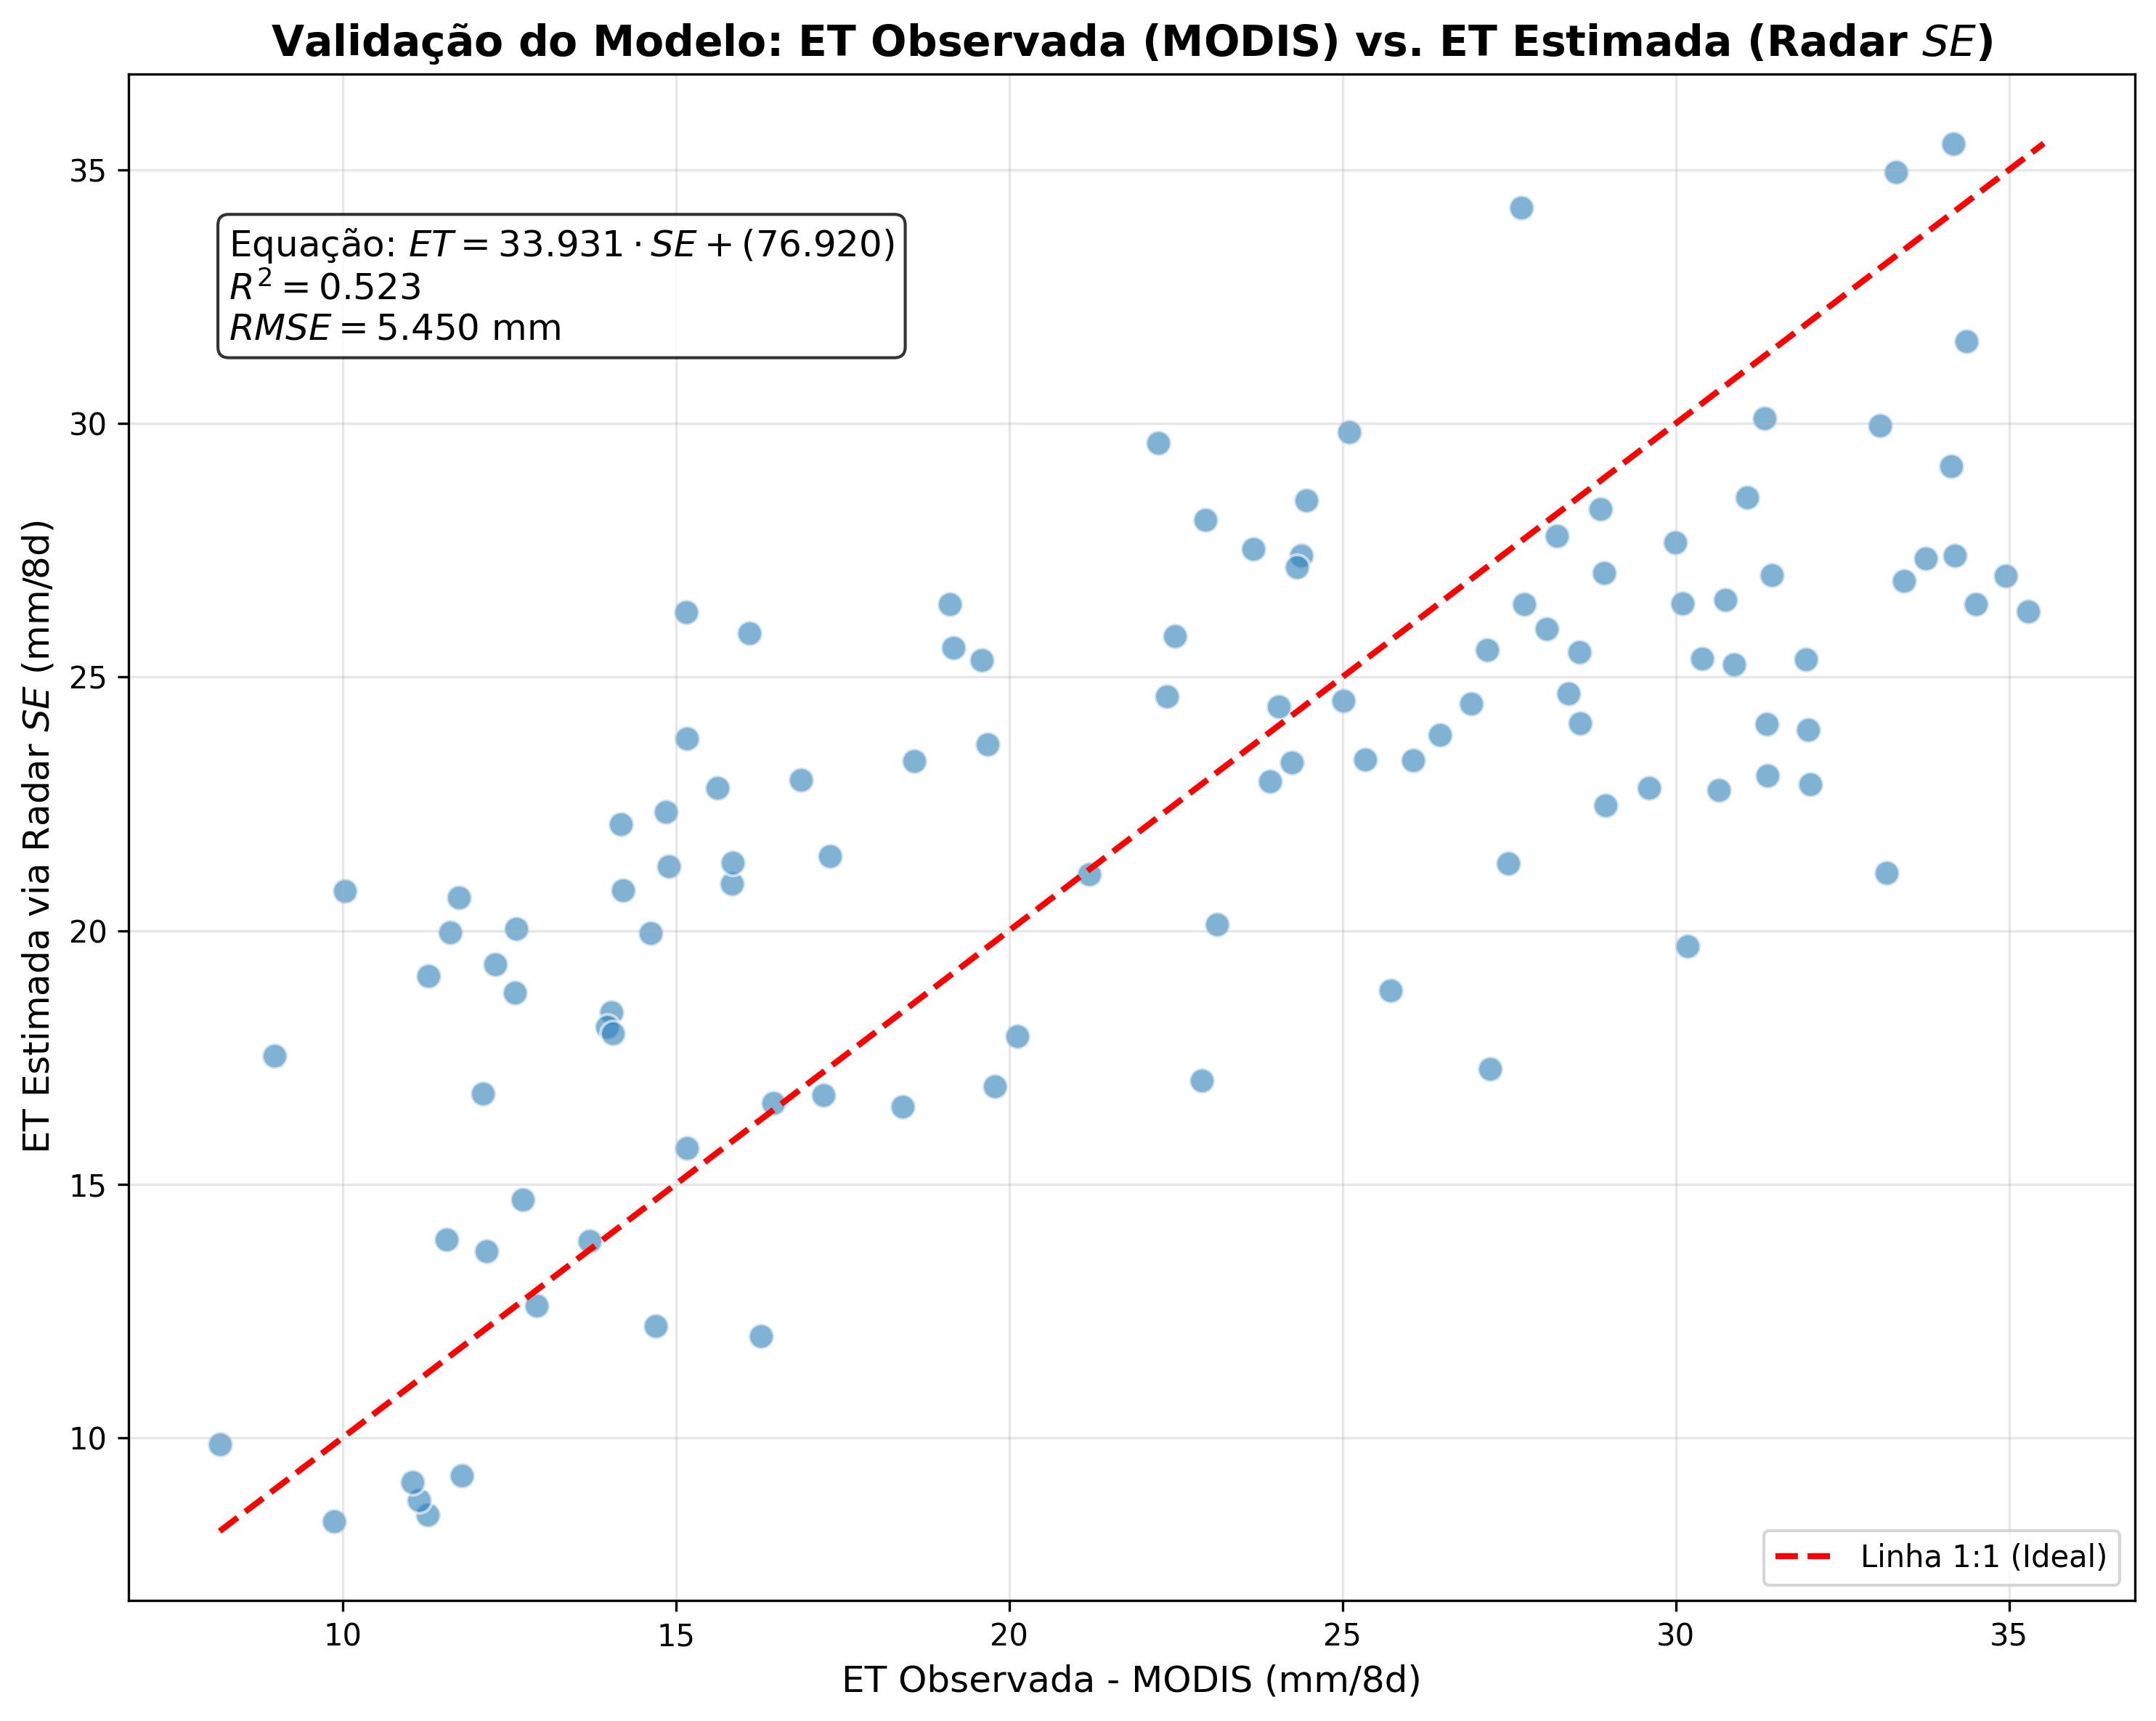

🚀 Modelo Finalizado!
➜ Equação Sugerida para o Artigo: ET = 33.9311 * SE + (76.9203)


In [ ]:
# ==============================================================================
# Célula 6 - MODELO PREDITIVO LINEAR (ESTIMANDO ET VIA RADAR)
# Aplicando Regressão Linear para converter Estrutura em Metabolismo.
# ==============================================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Preparação dos dados (usando o período 2021-2025 onde temos ET)
df_model = df_final.dropna(subset=['SE_smooth', 'ET_smooth']).copy()

X = df_model[['SE_smooth']].values # Preditores (Radar)
y = df_model['ET_smooth'].values    # Alvo (Metabolismo)

# 2. Treinamento do Modelo
modelo_et = LinearRegression()
modelo_et.fit(X, y)
y_pred = modelo_et.predict(X)

# 3. Estatísticas de Performance
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
slope = modelo_et.coef_[0]
intercept = modelo_et.intercept_

# 4. Plotagem de Validação (Observado vs. Predito)
plt.figure(figsize=(10, 8))
plt.scatter(y, y_pred, alpha=0.6, color='#2c7fb8', edgecolors='white', s=70)

# Linha 1:1 (Perfeição)
lims = [np.min([y.min(), y_pred.min()]), np.max([y.max(), y_pred.max()])]
plt.plot(lims, lims, 'r--', lw=2, label='Linha 1:1 (Ideal)')

plt.title('Validação do Modelo: ET Observada (MODIS) vs. ET Estimada (Radar $SE$)',
          fontsize=14, fontweight='bold')
plt.xlabel('ET Observada - MODIS (mm/8d)', fontsize=12)
plt.ylabel('ET Estimada via Radar $SE$ (mm/8d)', fontsize=12)

# Equação e Métricas no gráfico
plt.text(0.05, 0.90, f'Equação: $ET = {slope:.3f} \cdot SE + ({intercept:.3f})$\n$R^2 = {r2:.3f}$\n$RMSE = {rmse:.3f}$ mm',
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"🚀 Modelo Finalizado!")
print(f"➜ Equação Sugerida para o Artigo: ET = {slope:.4f} * SE + ({intercept:.4f})")

In [ ]:
# ==============================================================================
# ARTIGO - Célula 9 - CONFRONTO DE MODELOS (Linear vs. Random Forest vs. SVR)
# Objetivo: Superar o R2 de 0.52 com abordagens multivariadas.
# ==============================================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold # Corrigido aqui
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Seleção das Features (X) e Alvo (y)
# Vamos usar o "Time de Elite" de preditores que identificamos antes
features_elite = ['SE_smooth', 'DoP_smooth', 'LST_smooth', 'Soil_Moisture']
df_ml = df_final.dropna(subset=features_elite + ['ET_smooth']).copy()

X = df_ml[features_elite].values
y = df_ml['ET_smooth'].values

# Normalização (Essencial para SVR e Linear, opcional para RF mas ajuda na comparação)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Definição dos Modelos
modelos = {
    "Regressão Linear Múltipla": LinearRegression(),
    "Random Forest (100 árvores)": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR (Kernel RBF)": SVR(kernel='rbf', C=1.0, epsilon=0.1)
}

print(f"🧪 Testando modelos em {len(df_ml)} amostras (Janela 2021-2025)...")
print("-" * 60)

# 3. Execução do Torneio
for nome, model in modelos.items():
    # Validação Cruzada de 5 dobras para evitar overfitting
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(model, X_scaled, y, cv=kf, scoring='r2')
    rmse_scores = cross_val_score(model, X_scaled, y, cv=kf, scoring='neg_root_mean_squared_error')

    print(f"📊 {nome}:")
    print(f"   ➜ R² Médio: {scores.mean():.3f} (+/- {scores.std():.2f})")
    print(f"   ➜ RMSE Médio: {abs(rmse_scores.mean()):.3f} mm/8d")
    print("-" * 60)

🧪 Testando modelos em 111 amostras (Janela 2021-2025)...
------------------------------------------------------------
📊 Regressão Linear Múltipla:
   ➜ R² Médio: 0.856 (+/- 0.05)
   ➜ RMSE Médio: 2.916 mm/8d
------------------------------------------------------------
📊 Random Forest (100 árvores):
   ➜ R² Médio: 0.816 (+/- 0.07)
   ➜ RMSE Médio: 3.224 mm/8d
------------------------------------------------------------
📊 SVR (Kernel RBF):
   ➜ R² Médio: 0.836 (+/- 0.04)
   ➜ RMSE Médio: 3.152 mm/8d
------------------------------------------------------------


/tmp/ipykernel_14869/616954401.py:37: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14869/616954401.py:37: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


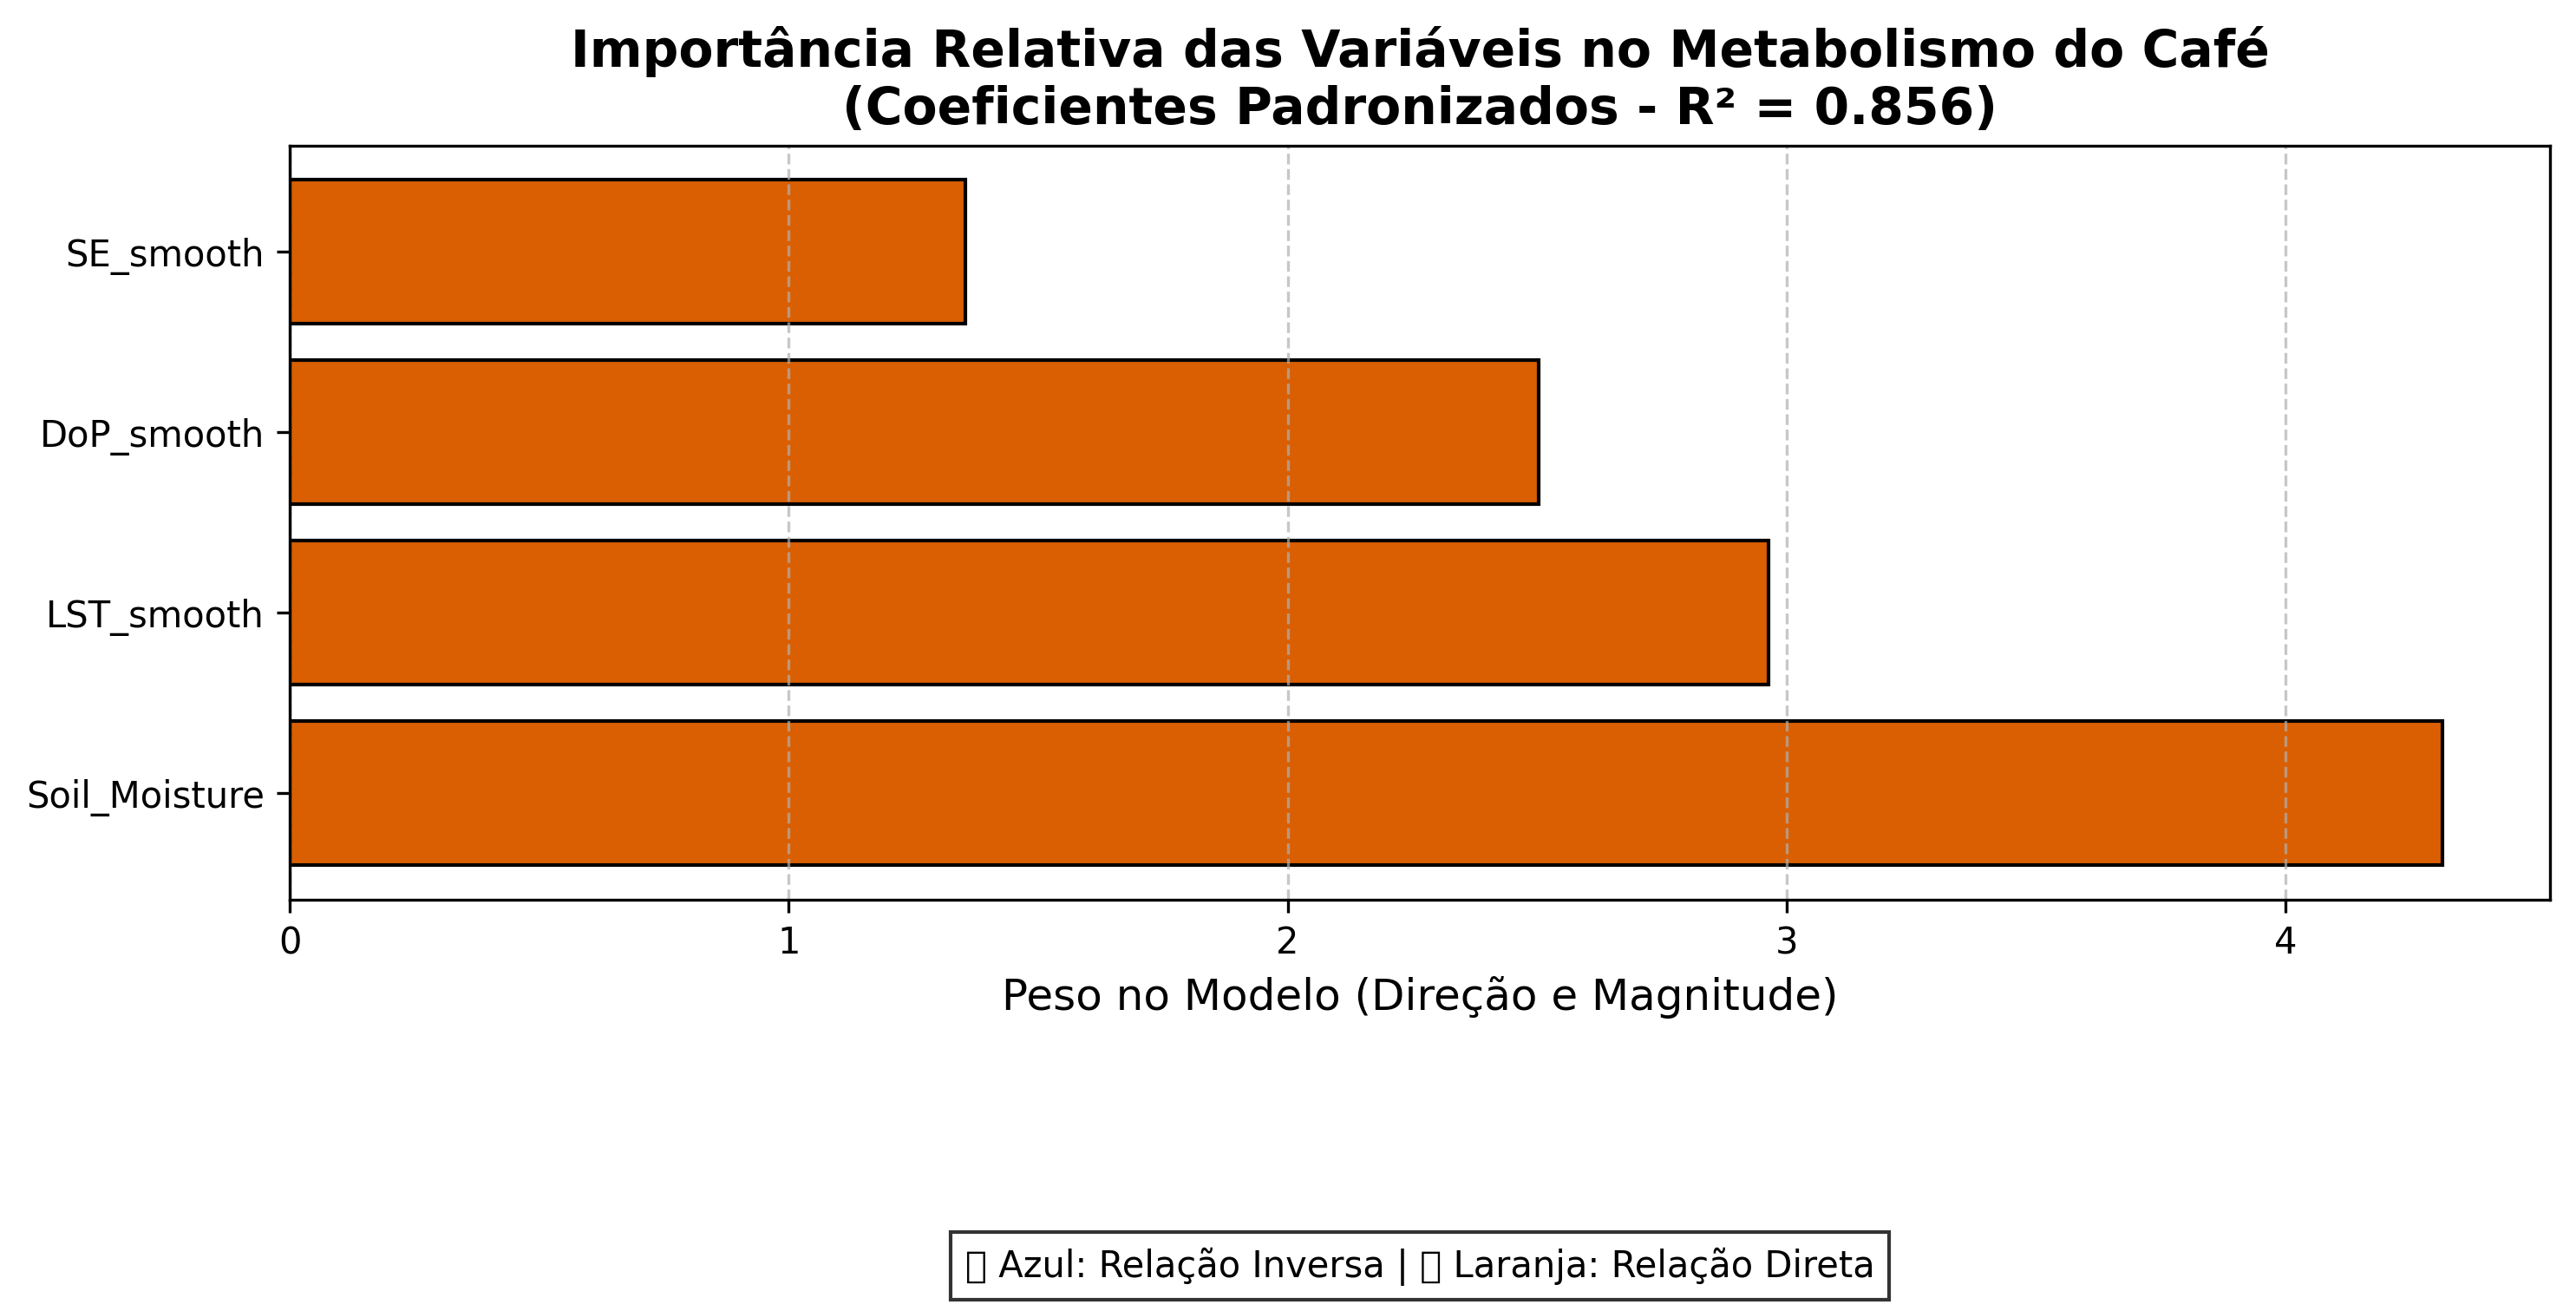

------------------------------------------------------------
📝 HIERARQUIA DE INFLUÊNCIA NO CAFÉ:
➜ Soil_Moisture   | Peso:   4.314 | (Aumenta a ET)
➜ LST_smooth      | Peso:   2.965 | (Aumenta a ET)
➜ DoP_smooth      | Peso:   2.503 | (Aumenta a ET)
➜ SE_smooth       | Peso:   1.354 | (Aumenta a ET)
------------------------------------------------------------


In [ ]:
# ==============================================================================
# ARTIGO - Célula 10 - PESOS DO MODELO (Feature Importance)
# Identificando o protagonismo de cada sensor no R2 de 0.856.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt

# 1. Ajustamos o modelo campeão no conjunto total (dados padronizados)
modelo_final = LinearRegression()
modelo_final.fit(X_scaled, y)

# 2. Extraímos os coeficientes
importancias = pd.DataFrame({
    'Variável': features_elite,
    'Peso (Coeficiente)': modelo_final.coef_
})

# Ordenar por impacto absoluto
importancias['Impacto_Absoluto'] = importancias['Peso (Coeficiente)'].abs()
importancias = importancias.sort_values(by='Impacto_Absoluto', ascending=False)

# 3. Visualização
plt.figure(figsize=(10, 6))
colors = ['#d95f02' if x > 0 else '#2c7fb8' for x in importancias['Peso (Coeficiente)']]
plt.barh(importancias['Variável'], importancias['Peso (Coeficiente)'], color=colors, edgecolor='black')

plt.axvline(0, color='black', linestyle='-', linewidth=1)
plt.title('Importância Relativa das Variáveis no Metabolismo do Café\n(Coeficientes Padronizados - R² = 0.856)', fontsize=14, fontweight='bold')
plt.xlabel('Peso no Modelo (Direção e Magnitude)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Anotação explicativa
plt.text(0.5, -0.5, "🔵 Azul: Relação Inversa | 🟠 Laranja: Relação Direta",
         transform=plt.gca().transAxes, ha='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("-" * 60)
print("📝 HIERARQUIA DE INFLUÊNCIA NO CAFÉ:")
for i, row in importancias.iterrows():
    direcao = "Aumenta" if row['Peso (Coeficiente)'] > 0 else "Diminui"
    print(f"➜ {row['Variável']:<15} | Peso: {row['Peso (Coeficiente)']:>7.3f} | ({direcao} a ET)")
print("-" * 60)


========================= SUMÁRIO DA REGRESSÃO =========================
                            OLS Regression Results                            
Dep. Variable:              ET_smooth   R-squared:                       0.872
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                     180.8
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           2.13e-46
Time:                        21:13:03   Log-Likelihood:                -272.59
No. Observations:                 111   AIC:                             555.2
Df Residuals:                     106   BIC:                             568.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

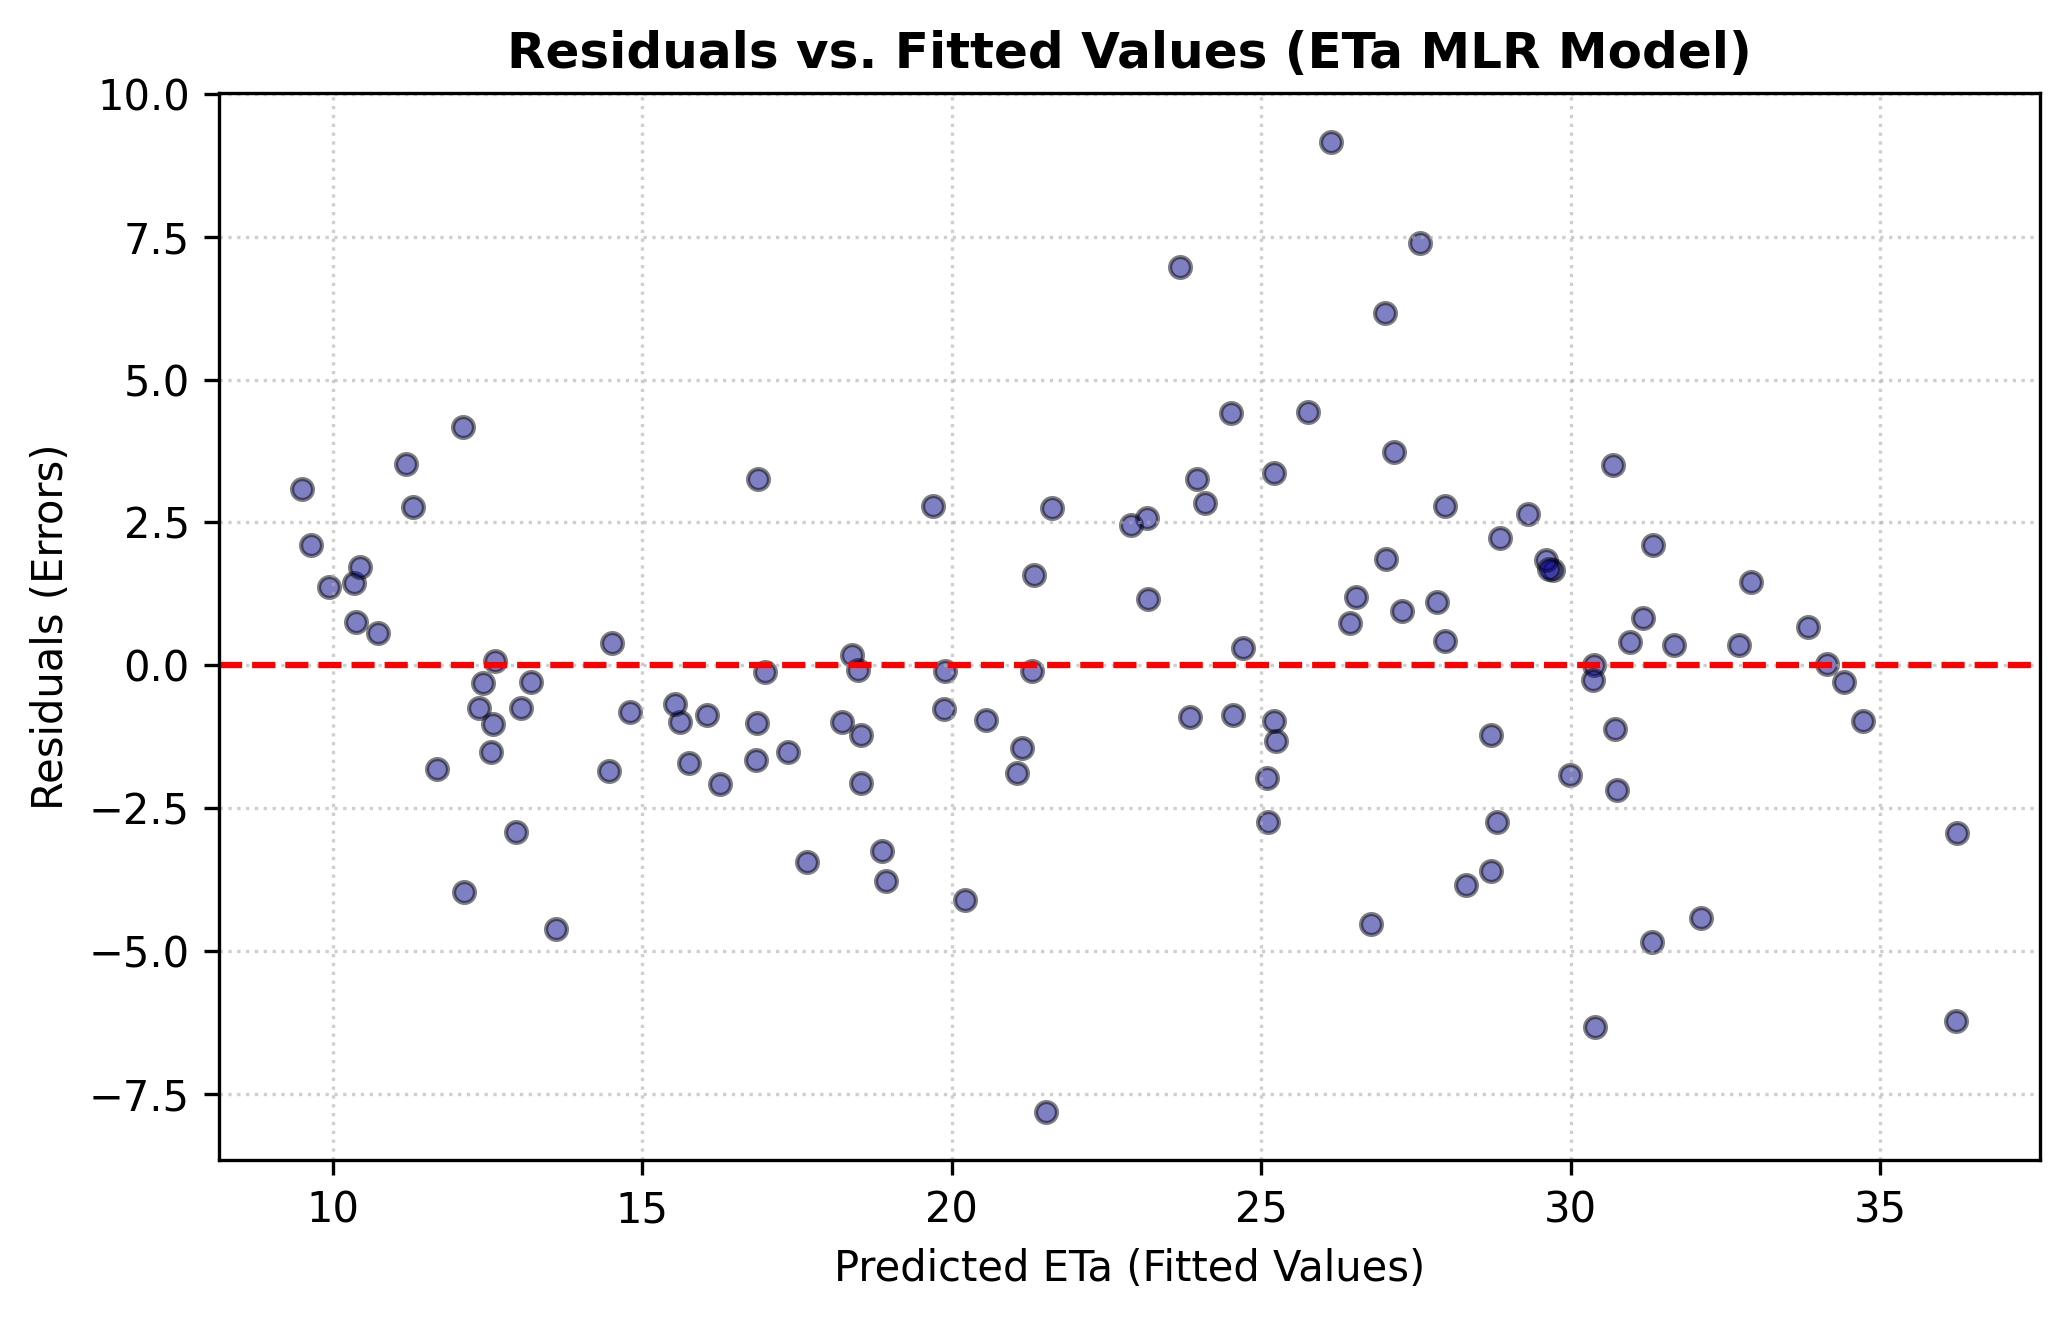

In [ ]:
# Novo ajuste (0,87)
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Configuração das colunas com base no seu df_final
# Defina aqui se o seu alvo foi 'ET_smooth' ou 'ET' no manuscrito:
target_column = 'ET_smooth'  # Altere para 'ET' se foi o dado bruto
X_columns = ['Soil_Moisture', 'LST_smooth', 'DoP_smooth', 'SE_smooth']

# Remove linhas com valores vazios (NaN) para não quebrar a regressão
df_clean = df_final[[target_column] + X_columns].dropna()

X = df_clean[X_columns]
y = df_clean[target_column]

# Adiciona a constante da regressão linear (intercepto)
X_with_const = sm.add_constant(X)

# 2. Ajusta o modelo de Regressão Linear Múltipla (MLR)
model = sm.OLS(y, X_with_const).fit()

# Imprime o relatório com P-valores e Intervalos de Confiança (Tabela 2 e 4)
print("\n" + "="*25 + " SUMÁRIO DA REGRESSÃO " + "="*25)
print(model.summary())

# 3. Calcula o VIF para cada variável preditora (Multicolinearidade)
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\n" + "="*20 + " ANÁLISE DE MULTICOLINEARIDADE (VIF) " + "="*20)
print(vif_data)

# 4. GERAÇÃO DO GRÁFICO DE RESÍDUOS (Exigência do Revisor 1)
residuals = model.resid
fitted_values = model.fittedvalues

plt.figure(figsize=(7, 4.5))
plt.scatter(fitted_values, residuals, alpha=0.5, color='darkblue', edgecolors='k', s=25)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.title('Residuals vs. Fitted Values (ETa MLR Model)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted ETa (Fitted Values)', fontsize=10)
plt.ylabel('Residuals (Errors)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Salva o gráfico em alta resolução para a revista
plt.savefig('model_residuals_plot.png', dpi=300)
print("\n" + "="*50)
print("-> SUCESSO: Gráfico de resíduos salvo como 'model_residuals_plot.png'")
print("="*50)

In [ ]:
# Código rápido para recalcular o VIF com dados centralizados na média
X_centered = X - X.mean()

vif_centered = pd.DataFrame()
vif_centered["Variable"] = X_centered.columns
vif_centered["VIF_Real"] = [variance_inflation_factor(X_centered.values, i) for i in range(X_centered.shape[1])]

print("\n=== ANÁLISE DE VIF CORRIGIDA (CENTRALIZADA) ===")
print(vif_centered)